# Fashion-MNIST Classification with a Multilayer Perceptron (PyTorch)

## Project Description

This project implements a multilayer perceptron (MLP) for classifying the 10 classes of the Fashion-MNIST dataset using PyTorch.

The model is trained using `CrossEntropyLoss` and optimized with Stochastic Gradient Descent (SGD) with momentum.

## Evaluation and Analysis

The model is evaluated using training and test accuracy after each epoch. The project also includes:

- Training and test accuracy plotted per epoch.
- A confusion matrix for the 10 Fashion-MNIST classes.
- Training loss plotted per epoch.
- SGD optimization with momentum.
- A percentage-based confusion matrix visualized as a heatmap.

# Implementation

## Libraries and Device Configuration

Import the required libraries and configure the computation device for model training. The implementation automatically uses the GPU when CUDA is available; otherwise, it falls back to the CPU.

In [1]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from typing import Final, List
import numpy as np
import matplotlib.pyplot as plt

device: Final[torch.device] = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"Using PyTorch version: {torch.__version__} | Device: {device}")

Using PyTorch version: 2.7.1+cu128 | Device: cuda


### Model Summary Utility

In [2]:
from torchsummary import summary

# Dataset Preparation

## Loading and Transforming the Fashion-MNIST Dataset

Download the dataset, convert the images to tensors, and prepare the DataLoaders for batch processing.

In [3]:
# Import the base Dataset class
from torch.utils.data import Dataset

In [4]:
from torch.utils.data import DataLoader

transform: transforms.ToTensor = transforms.ToTensor()

train_ds: datasets.FashionMNIST = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_ds: datasets.FashionMNIST = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

In [5]:
batch_size: int = 32

train_loader: DataLoader = DataLoader(
    train_ds,
    batch_size=batch_size,
    shuffle=True
)

test_loader: DataLoader = DataLoader(
    test_ds,
    batch_size=batch_size,
    shuffle=False
)

data: torch.Tensor
label: torch.Tensor

for data, label in train_loader:
    print(data.shape, label.shape)
    break

torch.Size([32, 1, 28, 28]) torch.Size([32])


## Visualizing Training Set Samples

Display a selection of images from the training set together with their corresponding class labels.

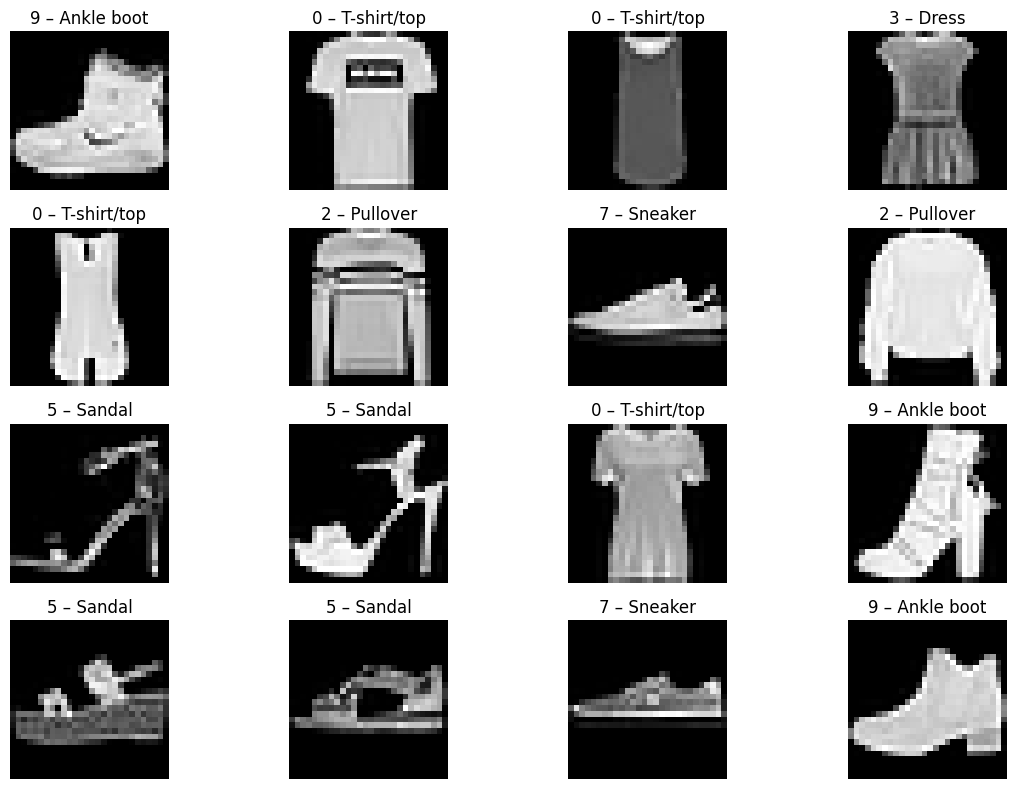

In [6]:
fashion_mnist_labels: list[str] = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]


def show_samples_torch(
    dataset: Dataset,
    n_samples: int = 16
) -> None:
    fig: plt.Figure
    ax: np.ndarray

    fig, ax = plt.subplots(
        n_samples // 4,
        4,
        figsize=(12, 8)
    )

    k: int
    for k in range(n_samples):
        row: int
        col: int
        x: torch.Tensor
        y: int

        row, col = k // 4, k % 4
        x, y = dataset[k]

        img: torch.Tensor = x.squeeze(0)
        label_name: str = fashion_mnist_labels[y]

        ax[row, col].imshow(img, cmap="gray")
        ax[row, col].set_title(f"{y} – {label_name}")
        ax[row, col].axis("off")

    plt.tight_layout()
    plt.show()


show_samples_torch(train_ds, n_samples=16)

# Defining the Multilayer Perceptron (MLP)

A feed-forward neural network with two hidden layers and ReLU activation functions.

In [7]:
class MLP(nn.Module):
    def __init__(
        self,
        input_size: int = 784,
        hidden_layers: List[int] = [256, 128],
        num_classes: int = 10
    ) -> None:
        super().__init__()

        layers: List[nn.Module] = []
        prev_size: int = input_size

        h: int
        for h in hidden_layers:
            layers.append(nn.Linear(prev_size, h))
            layers.append(nn.ReLU())
            prev_size = h

        layers.append(nn.Linear(prev_size, num_classes))
        self.net: nn.Sequential = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x.view(x.size(0), -1)
        return self.net(x)


model: MLP = MLP(hidden_layers=[256, 128]).to(device)
print(model)

MLP(
  (net): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)


## Verifying the MLP Model and Output Dimensions

Before training, we verify that the model works correctly and produces logits with the expected shape `(batch_size, 10)`.

The default batch size is 32, so the expected output shape is `torch.Size([32, 10])`.

In [8]:
x: torch.Tensor
y: torch.Tensor

x, y = next(iter(train_loader))
x = x.to(device)

logits: torch.Tensor = model(x)
print(logits.shape)

torch.Size([32, 10])


### Model Architecture and Parameter Count

Display the model architecture and the number of trainable parameters.

In [9]:
summary(model, input_size=(1, 28, 28), device=str(device));

Layer (type:depth-idx)                   Param #
├─Sequential: 1-1                        --
|    └─Linear: 2-1                       200,960
|    └─ReLU: 2-2                         --
|    └─Linear: 2-3                       32,896
|    └─ReLU: 2-4                         --
|    └─Linear: 2-5                       1,290
Total params: 235,146
Trainable params: 235,146
Non-trainable params: 0


# Defining the Loss Function and Optimizer (SGD + Momentum)

For multi-class classification, we use `CrossEntropyLoss`.

In [10]:
loss_fn: nn.CrossEntropyLoss = nn.CrossEntropyLoss()

optimizer: torch.optim.Optimizer = torch.optim.SGD(
    model.parameters(),
    lr=1e-3,
    momentum=0.9
)

# Accuracy Evaluation Function

Evaluate the model's performance on the training and test datasets.

In [11]:
def accuracy_torch(
    model: nn.Module,
    data_loader: DataLoader,
    device: torch.device
) -> float:
    model.eval()

    correct: int = 0
    total: int = 0

    with torch.no_grad():
        x: torch.Tensor
        y: torch.Tensor

        for x, y in data_loader:
            x = x.to(device)
            y = y.to(device)

            logits: torch.Tensor = model(x)
            preds: torch.Tensor = torch.argmax(logits, dim=1)

            correct += torch.sum(preds == y).item()
            total += y.size(0)

    return 100.0 * correct / total

# Training Loop and Metric Collection

Train the model for multiple epochs, compute the training loss, and record the training and test accuracy for later visualization.

In [12]:
epochs: int = 20

train_acc_list: list[float] = []
test_acc_list: list[float] = []
train_loss_list: list[float] = []

epoch: int
for epoch in range(epochs):
    model.train()
    running_loss: float = 0.0

    x: torch.Tensor
    y: torch.Tensor

    for x, y in train_loader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        logits: torch.Tensor = model(x)
        loss: torch.Tensor = loss_fn(logits, y)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss: float = running_loss / len(train_loader)
    train_loss_list.append(avg_loss)

    train_acc: float = accuracy_torch(model, train_loader, device)
    test_acc: float = accuracy_torch(model, test_loader, device)

    train_acc_list.append(train_acc)
    test_acc_list.append(test_acc)

    print(
        f"Epoch {epoch + 1}/{epochs} | "
        f"Loss: {avg_loss:.4f} | "
        f"Train acc: {train_acc:.2f}% | "
        f"Test acc: {test_acc:.2f}%"
    )

Epoch 1/20 | Loss: 1.0700 | Train acc: 77.56% | Test acc: 76.37%
Epoch 2/20 | Loss: 0.5751 | Train acc: 82.04% | Test acc: 80.42%
Epoch 3/20 | Loss: 0.4945 | Train acc: 82.88% | Test acc: 81.77%
Epoch 4/20 | Loss: 0.4585 | Train acc: 84.64% | Test acc: 83.18%
Epoch 5/20 | Loss: 0.4366 | Train acc: 85.26% | Test acc: 83.72%
Epoch 6/20 | Loss: 0.4193 | Train acc: 85.27% | Test acc: 83.97%
Epoch 7/20 | Loss: 0.4047 | Train acc: 86.28% | Test acc: 84.58%
Epoch 8/20 | Loss: 0.3909 | Train acc: 86.55% | Test acc: 84.74%
Epoch 9/20 | Loss: 0.3799 | Train acc: 86.74% | Test acc: 85.12%
Epoch 10/20 | Loss: 0.3688 | Train acc: 87.31% | Test acc: 85.54%
Epoch 11/20 | Loss: 0.3610 | Train acc: 87.39% | Test acc: 85.67%
Epoch 12/20 | Loss: 0.3515 | Train acc: 87.80% | Test acc: 85.97%
Epoch 13/20 | Loss: 0.3419 | Train acc: 87.41% | Test acc: 85.22%
Epoch 14/20 | Loss: 0.3356 | Train acc: 88.21% | Test acc: 86.25%
Epoch 15/20 | Loss: 0.3277 | Train acc: 88.94% | Test acc: 86.96%
Epoch 16/20 | Loss:

# Training and Test Accuracy

Comparison of training and test accuracy across epochs.

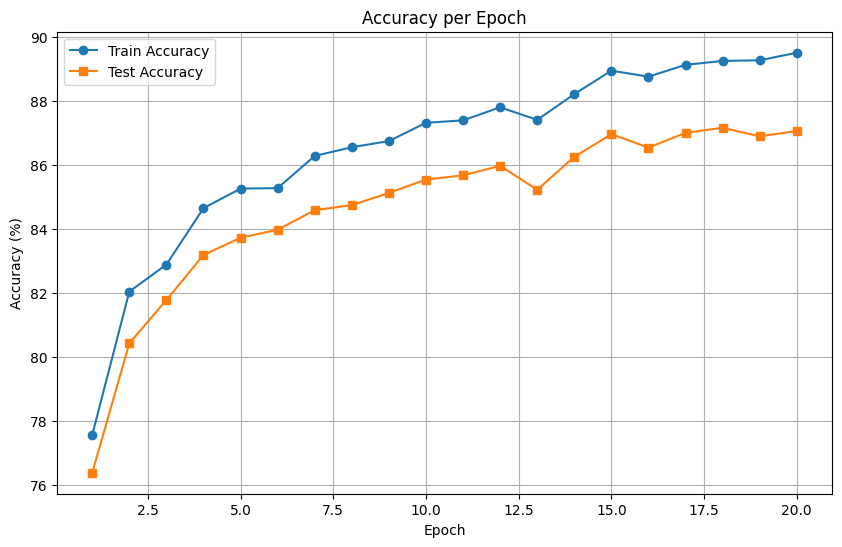

In [13]:
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, epochs + 1),
    train_acc_list,
    label="Train Accuracy",
    marker="o"
)

plt.plot(
    range(1, epochs + 1),
    test_acc_list,
    label="Test Accuracy",
    marker="s"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy per Epoch")
plt.legend()
plt.grid(True)
plt.show()

# Absolute Confusion Matrix on the Test Set

Analyze the distribution of correct and incorrect predictions across the ten classes.

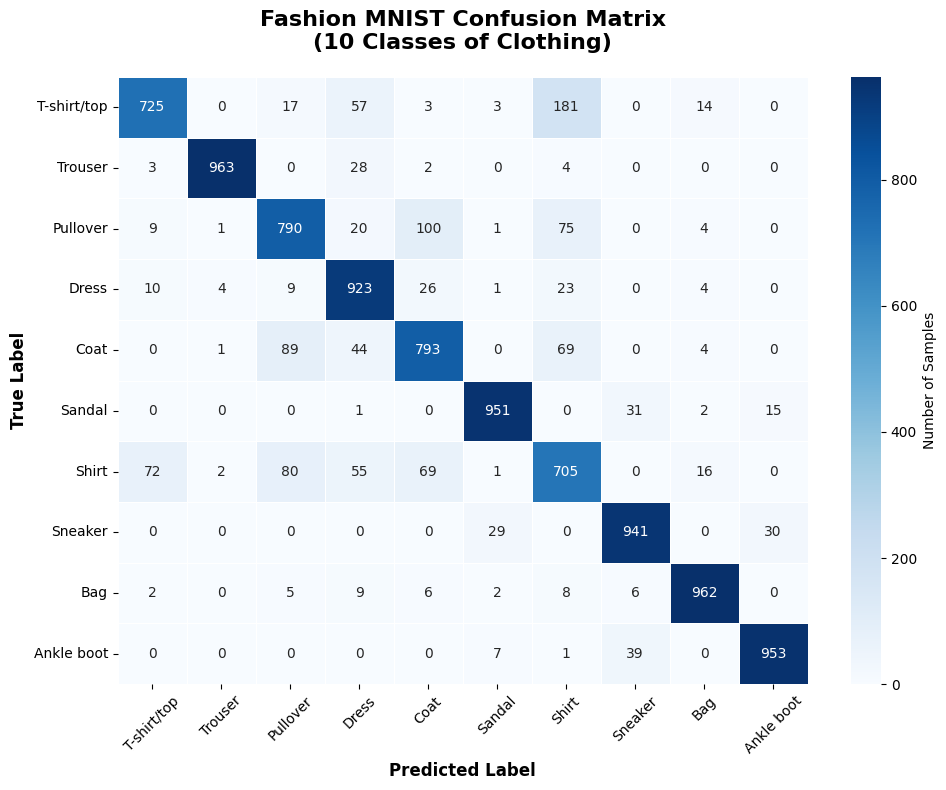

In [14]:
from sklearn.metrics import confusion_matrix
import seaborn as sns


model.eval()

all_preds: list[int] = []
all_true: list[int] = []


with torch.no_grad():
    for x, y in test_loader:
        x: torch.Tensor = x.to(device)
        y: torch.Tensor = y.to(device)

        logits: torch.Tensor = model(x)
        preds: torch.Tensor = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_true.extend(y.cpu().numpy())


cm: np.ndarray = confusion_matrix(all_true, all_preds)


labels_names: list[str] = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]


plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels_names,
    yticklabels=labels_names,
    linewidths=0.5,
    cbar_kws={"label": "Number of Samples"}
)

plt.title(
    "Fashion MNIST Confusion Matrix\n(10 Classes of Clothing)",
    fontsize=16,
    fontweight="bold",
    pad=20
)
plt.xlabel("Predicted Label", fontsize=12, fontweight="bold")
plt.ylabel("True Label", fontsize=12, fontweight="bold")
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

The MLP achieves 87.06% test accuracy, with most classification errors occurring among visually similar upper-body clothing classes such as Shirt, T-shirt/top, Pullover, and Coat. Distinctive categories such as Trouser, Bag, Sneaker, Sandal, and Ankle boot achieve considerably higher classification accuracy.

# Percentage Confusion Matrix (Normalized Heatmap)

Row-normalized confusion matrix showing the classification accuracy for each class.

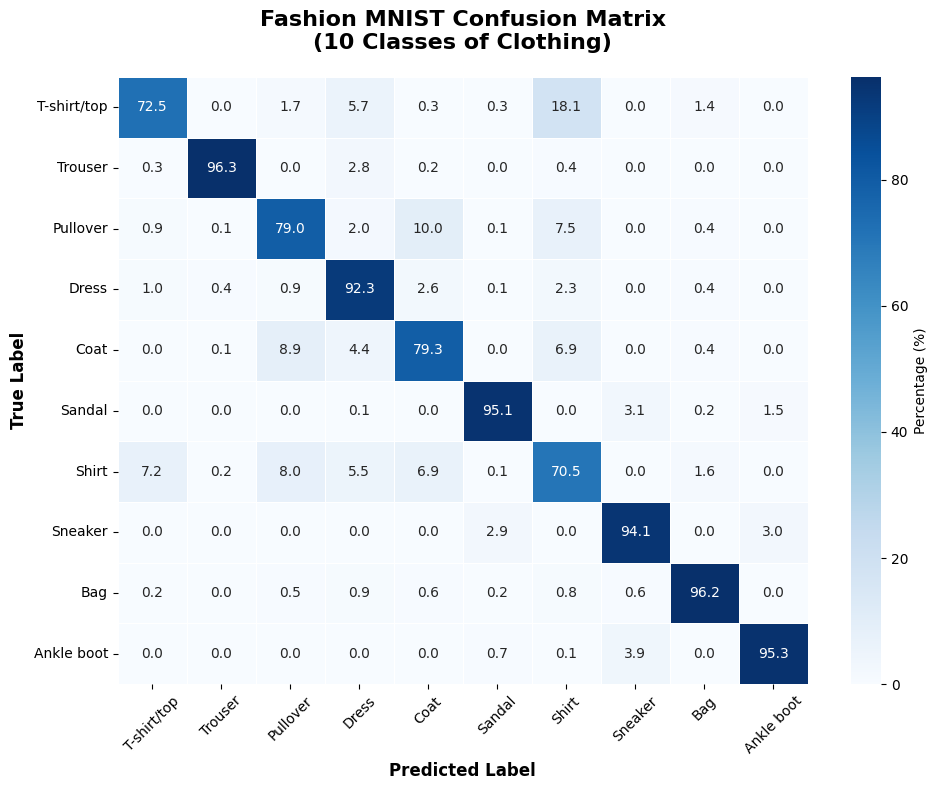

In [15]:
cm_percent: np.ndarray = (
    cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm_percent,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    xticklabels=labels_names,
    yticklabels=labels_names,
    linewidths=0.5,
    cbar_kws={"label": "Percentage (%)"}
)

plt.title(
    "Fashion MNIST Confusion Matrix\n(10 Classes of Clothing)",
    fontsize=16,
    fontweight="bold",
    pad=20
)
plt.xlabel("Predicted Label", fontsize=12, fontweight="bold")
plt.ylabel("True Label", fontsize=12, fontweight="bold")
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

# Training Loss per Epoch

Visualize the evolution of the training loss across epochs.

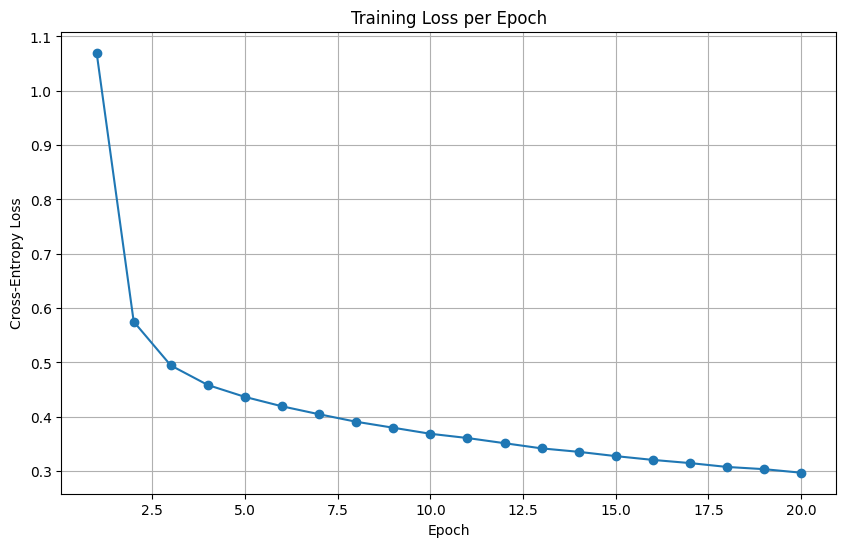

In [16]:
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, epochs + 1),
    train_loss_list,
    marker="o"
)

plt.title("Training Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.grid(True)
plt.show()